# Evaluation 05 — box plots por papel e agregado

Compara modelos a partir de arquivos de previsão em formato wide: `step` + uma coluna por papel.

Cada papel/coluna é tratado como seu próprio grupo de comparação. O agregado também é exibido. Os outliers ficam visíveis nos box plots.


In [24]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


CONFIG = {
    'col_step_previsao': 'step',
    'col_lote_previsao': None,
    'candidatos_col_lote_previsao': ['janela', 'janela_id', 'lote', 'lote_id', 'window', 'window_id', 'batch', 'batch_id', 'origin', 'cutoff', 'rolling_origin'],
    'col_step_real': 'date',
    'col_valor_real': 'data',
    'col_papel_real': 'cols',
    'pastas_dados_reais': ['../data', './data', '../datasets', './datasets', '.', '/mnt/data'],
    'arquivos_dados_reais': {
        'b3_daily_financeiro_indice': 'b3_daily_financeiro_indice.csv',
        'financeiro_indice': 'b3_daily_financeiro_indice.csv',
        'b3_daily_financeiro_ohlcv': 'b3_daily_financeiro_ohlcv.csv',
    },
    'padroes_previsao': ['*.parquet', '*.csv', '*.feather', '*.pkl', '*.pickle'],
    'ignorar_arquivos_contendo': ['train_loss', 'loss', 'history', 'metric', 'metrics', 'resumo', 'summary', 'config', 'checkpoint', 'model', 'scaler', 'normalizer'],
}

PALETA_PADRAO = plt.rcParams['axes.prop_cycle'].by_key()['color']


In [25]:
def ler_arquivo(path):
    path = Path(path)
    ext = path.suffix.lower()
    if ext == '.csv':
        return pd.read_csv(path)
    if ext == '.parquet':
        return pd.read_parquet(path)
    if ext == '.feather':
        return pd.read_feather(path)
    if ext in {'.pkl', '.pickle'}:
        return pd.read_pickle(path)
    raise ValueError('Extensão não suportada: ' + str(path))

def inferir_dataset(endereco):
    partes = Path(str(endereco)).parts
    if 'previsoes' in partes:
        i = partes.index('previsoes')

        # caso TFB: previsoes/tfb/<dataset>/<lookback>/<modelo>
        if i + 2 < len(partes) and partes[i + 1] == 'tfb':
            return partes[i + 2]

        # caso padrão: previsoes/<dataset>/...
        if i + 1 < len(partes):
            return partes[i + 1]

    return None

def localizar_real(reg, cfg):
    if reg.get('dados_reais'):
        p = Path(reg['dados_reais']).expanduser()
        if p.exists():
            return p
        raise FileNotFoundError(str(p))

    dataset = reg.get('dataset') or inferir_dataset(reg['endereco'])
    if not dataset:
        raise ValueError("Informe 'dataset' ou 'dados_reais' em registra_modelo.")

    nomes = []
    if dataset in cfg['arquivos_dados_reais']:
        nomes.append(cfg['arquivos_dados_reais'][dataset])
    nomes += [dataset + '.csv', dataset + '.parquet', dataset + '.feather']

    for pasta in cfg['pastas_dados_reais']:
        for nome in nomes:
            p = Path(pasta).expanduser() / nome
            if p.exists():
                return p
    raise FileNotFoundError('Dados reais não encontrados para dataset=' + str(dataset))


def carregar_real(reg, cfg):
    p = localizar_real(reg, cfg)
    df = ler_arquivo(p).copy()
    cs = cfg['col_step_real']
    cv = cfg['col_valor_real']
    cp = cfg['col_papel_real']

    if {cs, cv, cp}.issubset(df.columns):
        out = df[[cs, cv, cp]].rename(columns={cs: 'step', cv: 'y_true', cp: 'papel'})
    else:
        step_col = next((c for c in [cs, 'step', 'date', 'tempo', 'timestamp'] if c in df.columns), None)
        if step_col is None:
            raise ValueError('Coluna temporal não encontrada em ' + str(p))
        vals = [c for c in df.columns if c != step_col and pd.api.types.is_numeric_dtype(df[c])]
        out = df.melt(id_vars=[step_col], value_vars=vals, var_name='papel', value_name='y_true')
        out = out.rename(columns={step_col: 'step'})

    out['papel'] = out['papel'].astype(str)
    out['step'] = pd.to_numeric(out['step'], errors='coerce')
    out['y_true'] = pd.to_numeric(out['y_true'], errors='coerce')
    out = out.dropna(subset=['step', 'papel', 'y_true'])
    out['step'] = out['step'].astype(int)
    return out.drop_duplicates(['papel', 'step'], keep='last')


def arquivos_previsao(endereco, cfg):
    p = Path(endereco).expanduser()
    if p.is_file():
        return [p]
    if not p.exists():
        raise FileNotFoundError(str(p))

    arqs = []
    for padrao in cfg['padroes_previsao']:
        arqs.extend(list(p.rglob(padrao)))
    ignorar = [x.lower() for x in cfg['ignorar_arquivos_contendo']]
    return sorted({a for a in arqs if not any(x in a.name.lower() for x in ignorar)})


def carregar_previsoes(reg, real, cfg):
    tickers = set(real['papel'].astype(str).unique())
    partes = []
    ignorados = []

    for ordem_arq, arq in enumerate(arquivos_previsao(reg['endereco'], cfg)):
        try:
            df = ler_arquivo(arq).copy()
        except Exception as e:
            ignorados.append((arq, 'erro: ' + str(e)))
            continue

        step_col = cfg['col_step_previsao']
        if step_col not in df.columns:
            ignorados.append((arq, 'sem step'))
            continue

        ticker_cols = [c for c in df.columns if str(c) in tickers]
        if not ticker_cols:
            ignorados.append((arq, 'sem colunas de papéis dos dados reais'))
            continue

        df = df.dropna(subset=ticker_cols, how='all')
        if df.empty:
            continue

        df['_arquivo_origem'] = str(arq)
        df['_ordem_arquivo'] = ordem_arq
        df['_linha_no_arquivo'] = np.arange(len(df))

        long = df.melt(
            id_vars=[c for c in df.columns if c not in ticker_cols],
            value_vars=ticker_cols,
            var_name='papel',
            value_name='y_pred',
        )
        long = long.rename(columns={step_col: 'step'})
        long['modelo'] = reg['nome']
        long['step'] = pd.to_numeric(long['step'], errors='coerce')
        long['y_pred'] = pd.to_numeric(long['y_pred'], errors='coerce')
        long = long.dropna(subset=['step', 'papel', 'y_pred'])
        long['step'] = long['step'].astype(int)
        long['ordem_previsao'] = long['_ordem_arquivo'].astype('int64') * 10**12 + long['_linha_no_arquivo'].astype('int64')
        partes.append(long)

    if ignorados:
        print('Arquivos ignorados para', reg['nome'])
        for arq, motivo in ignorados[:15]:
            print('  -', arq, ':', motivo)

    if not partes:
        raise RuntimeError('Nenhum arquivo de previsão válido para ' + reg['nome'])
    return pd.concat(partes, ignore_index=True)


def aplicar_paradigma(pred, paradigma):
    keys = ['modelo', 'papel', 'step']
    if paradigma == 'median':
        return pred.groupby(keys, as_index=False).agg(
            y_pred=('y_pred', 'median'),
            n_previsoes=('y_pred', 'count'),
            primeira_ordem=('ordem_previsao', 'min'),
            ultima_ordem=('ordem_previsao', 'max'),
        )

    counts = pred.groupby(keys, as_index=False).size().rename(columns={'size': 'n_previsoes'})
    asc = paradigma == 'first'
    out = pred.sort_values(keys + ['ordem_previsao'], ascending=[True, True, True, asc])
    out = out.groupby(keys, as_index=False).first().merge(counts, on=keys, how='left')
    return out


def construir_base(registros, cfg, paradigma):
    if not registros:
        raise ValueError('Preencha registra_modelo antes de executar.')

    bases = []
    brutas = []
    for reg in registros:
        print('\nCarregando modelo:', reg['nome'])
        real = carregar_real(reg, cfg)
        raw = carregar_previsoes(reg, real, cfg)
        pred = aplicar_paradigma(raw, paradigma)
        base = pred.merge(real, on=['papel', 'step'], how='inner')
        if base.empty:
            raise RuntimeError('Merge previsão x real vazio para ' + reg['nome'])

        base['erro'] = base['y_pred'] - base['y_true']
        base['abs_error'] = base['erro'].abs()
        base['squared_error'] = base['erro'] ** 2
        print('  brutas=', len(raw), '| após paradigma=', len(pred), '| avaliadas=', len(base))
        bases.append(base)
        brutas.append(raw)

    return pd.concat(bases, ignore_index=True), pd.concat(brutas, ignore_index=True)


def detectar_lote(df, cfg):
    if cfg.get('col_lote_previsao') and cfg['col_lote_previsao'] in df.columns:
        return cfg['col_lote_previsao']
    for c in cfg['candidatos_col_lote_previsao']:
        if c in df.columns and df[c].nunique(dropna=True) > 1:
            return c
    return None

def boxplot_moderno(ax, df, metrica, titulo):
    ordem = df.groupby('modelo')[metrica].median().sort_values().index.tolist()
    #ordem = df.groupby('modelo')[metrica].median().index.tolist()
    dados = [df.loc[df['modelo'] == m, metrica].dropna().values for m in ordem]

    bp = ax.boxplot(
        dados,
        labels=ordem,
        patch_artist=True,
        showfliers=True,
        showmeans=True,
        widths=0.58,
        medianprops={'color': '#111111', 'linewidth': 2.2},
        whiskerprops={'color': '#555555', 'linewidth': 1.35},
        capprops={'color': '#555555', 'linewidth': 1.35},
        boxprops={'edgecolor': '#555555', 'linewidth': 1.15},
        flierprops={
            'marker': 'o',
            'markersize': 4.5,
            'markerfacecolor': '#ffffff',
            'markeredgecolor': '#c23b22',
            'markeredgewidth': 0.9,
            'alpha': 0.85,
        },
        meanprops={
            'marker': 'D',
            'markerfacecolor': '#1f1f1f',
            'markeredgecolor': 'white',
            'markersize': 5,
        },
    )

    for patch, modelo in zip(bp['boxes'], ordem):
        patch.set_facecolor(CORES.get(modelo, '#4c78a8'))
        patch.set_alpha(0.68)

    ax.set_title(titulo, weight='bold', pad=12)
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.8)
    ax.spines[['top', 'right']].set_visible(False)


def plot_grade_por_papel(df, metrica, max_cols=2):
    papeis = sorted(df['papel'].dropna().unique().tolist())
    if not papeis:
        return

    ncols = min(max_cols, len(papeis))
    nrows = int(np.ceil(len(papeis) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.9 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, papel in zip(axes, papeis):
        df_p = df[df['papel'] == papel]
        boxplot_moderno(ax, df_p, metrica, papel + ' — ' + metrica + ' — paradigma=' + PARADIGMA)

    for ax in axes[len(papeis):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def nome_arquivo_seguro(valor):
    valor = str(valor)
    valor = (
        valor.replace(' ', '_')
        .replace('/', '_')
        .replace('\\', '_')
        .replace('—', '-')
        .replace(':', '_')
    )
    return ''.join(c for c in valor if c.isalnum() or c in {'_', '-', '.'}).strip('_')

def salvar_figura(fig, nome_base):
    for formato in FORMATOS_GRAFICOS:
        fig.savefig(
            PASTA_GRAFICOS / f'{nome_base}.{formato}',
            dpi=DPI_GRAFICOS,
            bbox_inches='tight',
        )


def salvar_boxplot_agregado(df, metrica):
    fig, ax = plt.subplots(figsize=(10.8, 5.6))
    boxplot_moderno(
        ax,
        df,
        metrica,
        'Agregado — ' + metrica + ' — paradigma=' + PARADIGMA,
    )
    fig.tight_layout()

    nome_base = 'boxplot_agregado_' + nome_arquivo_seguro(metrica) + '_' + PARADIGMA
    salvar_figura(fig, nome_base)
    plt.close(fig)


def salvar_grade_por_papel(df, metrica, max_cols=2):
    papeis = sorted(df['papel'].dropna().unique().tolist())
    if not papeis:
        return

    ncols = min(max_cols, len(papeis))
    nrows = int(np.ceil(len(papeis) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7.2 * ncols, 4.9 * nrows),
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, papel in zip(axes, papeis):
        df_p = df[df['papel'] == papel]
        boxplot_moderno(
            ax,
            df_p,
            metrica,
            papel + ' — ' + metrica + ' — paradigma=' + PARADIGMA,
        )

    for ax in axes[len(papeis):]:
        ax.axis('off')

    fig.tight_layout()

    nome_base = 'boxplot_por_papel_' + nome_arquivo_seguro(metrica) + '_' + PARADIGMA
    salvar_figura(fig, nome_base)
    plt.close(fig)


In [10]:
# Paradigma de avaliação da janela deslizante:
#   'first'  -> primeira previsão de cada ponto
#   'median' -> mediana das previsões de cada ponto
#   'last'   -> última previsão de cada ponto
PARADIGMA = 'first'
assert PARADIGMA in {'first', 'median', 'last'}

# 'ponto' preserva a distribuição dos erros e exibe outliers.
# 'lote' agrega por janela/lote quando houver coluna de lote disponível.
UNIDADE_BOXPLOT = 'ponto'
#METRICAS = ['MAE', 'MSE']

METRICAS = ['MAE']


BUSCA_PASTA =    "mse/lookback_492/epochs_500"

NOME_PASTA_OUTPUT =   f'{BUSCA_PASTA}/modelos_IN'

# Edite este vetor. O dataset é inferido de ../previsoes/<dataset>/<modelo>/<data>.
# Se necessário, informe 'dataset' ou 'dados_reais' explicitamente.
registra_modelo = [
     #{'nome': 'Atenção','endereco':               f'previsoes/b3_daily_financeiro/{BUSCA_PASTA}/2026-06-04/AttentionSolo'},
     {'nome': 'AtenChanelIndep','endereco':       f'previsoes/b3_daily_financeiro/{BUSCA_PASTA}/2026-06-04/AttentionSoloChannelIndependent'},
     {'nome': 'AttChanIndepShrSpec','endereco':   f'previsoes/b3_daily_financeiro/{BUSCA_PASTA}/2026-06-04/AttentionSoloChannelIndependentSharedSpecific'},

     {'nome': 'AttChanIndepShrINSpec','endereco': f'previsoes/b3_daily_financeiro/{BUSCA_PASTA}/2026-06-04/AttentionSoloChannelIndependentSharedINSpecific'},

     #{'nome': 'Transformer','endereco':           f'previsoes/b3_daily_financeiro/{BUSCA_PASTA}/2026-06-04/TransformerChannelIndependent'},
     {'nome': 'TransformerSpec','endereco':       f'previsoes/b3_daily_financeiro/{BUSCA_PASTA}/2026-06-04/TransformerChannelIndependentSharedSpecific'},

     {'nome': 'TransfShrINSpec','endereco':       f'previsoes/b3_daily_financeiro/{BUSCA_PASTA}/2026-06-04/TransformerChannelIndependentSharedINSpecific'},
]

# Parâmetro: nome da pasta dentro de outputs/

for i, reg in enumerate(registra_modelo):
    reg.setdefault('cor', PALETA_PADRAO[i % len(PALETA_PADRAO)])


In [11]:
# Paradigma de avaliação da janela deslizante:
#   'first'  -> primeira previsão de cada ponto
#   'median' -> mediana das previsões de cada ponto
#   'last'   -> última previsão de cada ponto
PARADIGMA = 'first'
assert PARADIGMA in {'first', 'median', 'last'}

# 'ponto' preserva a distribuição dos erros e exibe outliers.
# 'lote' agrega por janela/lote quando houver coluna de lote disponível.
UNIDADE_BOXPLOT = 'ponto'
#METRICAS = ['MAE', 'MSE']

METRICAS = ['MAE']

BUSCA_PASTA =    "previsoes/b3_daily_financeiro_indice/mse/lookback_32/epochs_50"

NOME_PASTA_OUTPUT =   f'{BUSCA_PASTA}/modelos_IN'

# Edite este vetor. O dataset é inferido de ../previsoes/<dataset>/<modelo>/<data>.
# Se necessário, informe 'dataset' ou 'dados_reais' explicitamente.
registra_modelo = [
     #{'nome': 'Atenção','endereco':               f'previsoes/b3_daily_financeiro/{BUSCA_PASTA}/2026-06-04/AttentionSolo'},
     {'nome': 'AtenChanelIndep','endereco':       f'{BUSCA_PASTA}/AttentionSoloChannelIndependent', 'cor':"#0000FF"},
     {'nome': 'AttChanIndepShrINSpec','endereco': f'{BUSCA_PASTA}/AttentionSoloChannelIndependentSharedINSpecific', 'cor':"#E70E32"},
     {'nome': 'TransfShrINSpec','endereco':       f'{BUSCA_PASTA}/TransformerChannelIndependentSharedINSpecific', 'cor':"#27E70E"},
]

registra_modelo = [
     {'nome': 'AtenChanelIndep','endereco':       f'{BUSCA_PASTA}/AttentionSoloChannelIndependent', 'cor':"#0000FF"},
     {'nome': 'AttChanIndepShrINSpec','endereco': 'previsoes/b3_daily_financeiro_indice/mse/lookback_32/epochs_500/AttentionSoloChannelIndependentSharedINSpecific', 'cor':"#E70E32"},
]


# Parâmetro: nome da pasta dentro de outputs/

for i, reg in enumerate(registra_modelo):
    reg.setdefault('cor', PALETA_PADRAO[i % len(PALETA_PADRAO)])


In [12]:
# mesmo método/lookback várias épocas
BUSCA_PASTA = [
    #'mse/lookback_32/epochs_50',
    #'mse/lookback_32/epochs_100',
    'mse/lookback_32/epochs_250',
    'mse/lookback_32/epochs_500',
    #'mse/lookback_32/epochs_1000',
]

modelo = 'AttentionSoloChannelIndependentSharedINSpecific'
registra_modelo = []

for pasta in BUSCA_PASTA:
     partes_do_caminho = pasta.split('/')
     epoch = partes_do_caminho[2].replace('epochs_', '')
     registra_modelo.append({'nome': f'{epoch}','endereco':       f'previsoes/b3_daily_financeiro/{pasta}/2026-06-04/{modelo}', 'cor': "#0000FF" }) 
NOME_PASTA_OUTPUT =   'comparacao_entre_modelos/epoch_250'

# Parâmetro: nome da pasta dentro de outputs/

for i, reg in enumerate(registra_modelo):
    reg.setdefault('cor', PALETA_PADRAO[i % len(PALETA_PADRAO)])


In [4]:
# Comparação entre métodos por lookback
PARADIGMA = 'first'
UNIDADE_BOXPLOT = 'ponto'
#METRICAS = ['MAE', 'MSE']

METRICAS = ['MAE']
dataset='b3_daily_financeiro_indice'

BUSCA_PASTA = [
    'mse/lookback_32/epochs_50',
    'mse/lookback_32/epochs_100',
    'mse/lookback_32/epochs_250',
    'mse/lookback_32/epochs_500',
    #'mse/lookback_32/epochs_1000',
    #'mse/lookback_492/epochs_1000',
    #'mse/lookback_32/epochs_1000',
]

registra_modelo = []

for pasta in BUSCA_PASTA:
     partes_do_caminho = pasta.split('/')
     lookback = partes_do_caminho[1].replace('lookback_', '')
     epochs   = partes_do_caminho[2].replace('epochs_', '')
     
     tipo = epochs

     #registra_modelo.append({'nome': f'AtnSolo_{tipo}','endereco': f'previsoes/{dataset}/{pasta}/AttentionSolo', 'cor': "#0000FF" }) 
     registra_modelo.append({'nome': f'AtnChanlIndep_{tipo}','endereco': f'previsoes/{dataset}/{pasta}/AttentionSoloChannelIndependent', 'cor': "#0000FF9B" })

     #registra_modelo.append({'nome': f'AtnChanIndepShrSpec_{tipo}','endereco': f'previsoes/{dataset}/{pasta}/AttentionSoloChannelIndependentSharedSpecific', 'cor': "#FC3808E3"})
     registra_modelo.append({'nome': f'AtnChanIndepShrINSpec_{tipo}','endereco': f'previsoes/{dataset}/{pasta}/AttentionSoloChannelIndependentSharedINSpecific', 'cor': "#D64A2763"})

     #registra_modelo.append({'nome': f'TransChanIndep_{tipo}','endereco': f'previsoes/{dataset}/{pasta}/TransformerChannelIndependent', 'cor': "#2CDD15"})
     #registra_modelo.append({'nome': f'TransShrSpec_{tipo}','endereco': f'previsoes/{dataset}/{pasta}/TransformerChannelIndependentSharedSpecific', 'cor': "#A6E79D"})
     registra_modelo.append({'nome': f'TransShrINSpec_{tipo}','endereco': f'previsoes/{dataset}/{pasta}/TransformerChannelIndependentSharedINSpecific', 'cor': "#2CDD1539"})



NOME_PASTA_OUTPUT =   'comparacao_entre_modelos/epoch_250'


# Parâmetro: nome da pasta dentro de outputs/

for i, reg in enumerate(registra_modelo):
    reg.setdefault('cor', PALETA_PADRAO[i % len(PALETA_PADRAO)])


In [ ]:
registra_modelo = []
PARADIGMA = 'first'
UNIDADE_BOXPLOT = 'ponto'
#METRICAS = ['MAE', 'MSE']

METRICAS = ['MAE']
dataset='b3_daily_financeiro_indice'

#pasta =  'mse/lookback_492/epochs_'

#registra_modelo.append({'nome': f'AtnSolo_50','endereco': f'previsoes/b3_daily_financeiro/{pasta}50/AttentionSolo', 'cor': "#0000FF" }) 
#registra_modelo.append({'nome': f'AtnSolo_500','endereco': f'previsoes/b3_daily_financeiro/{pasta}500/AttentionSolo', 'cor': "#0000FF" }) 
#registra_modelo.append({'nome': f'AtnSolo_1000','endereco': f'previsoes/b3_daily_financeiro/{pasta}1000/AttentionSolo', 'cor': "#0000FF" }) 

#registra_modelo.append({'nome': f'AtnChanlIndep_50','endereco': f'previsoes/b3_daily_financeiro/{pasta}50/AttentionSoloChannelIndependent', 'cor': "#0000FF9B" })

#registra_modelo.append({'nome': f'AtnChanIndepShrSpec_50','endereco': f'previsoes/b3_daily_financeiro/{pasta}50/AttentionSoloChannelIndependentSharedSpecific', 'cor': "#FC3808E3"})
#registra_modelo.append({'nome': f'AtnChanIndepShrSpec_100','endereco': f'previsoes/b3_daily_financeiro/{pasta}100/AttentionSoloChannelIndependentSharedSpecific', 'cor': "#FC3808E3"})
#registra_modelo.append({'nome': f'AtnChanIndepShrSpec_250','endereco': f'previsoes/b3_daily_financeiro/{pasta}250/AttentionSoloChannelIndependentSharedSpecific', 'cor': "#FC3808E3"})
#registra_modelo.append({'nome': f'AtnChanIndepShrSpec_500','endereco': f'previsoes/b3_daily_financeiro/{pasta}500/AttentionSoloChannelIndependentSharedSpecific', 'cor': "#FC3808E3"})
#registra_modelo.append({'nome': f'AtnChanIndepShrSpec_1000','endereco': f'previsoes/b3_daily_financeiro/{pasta}1000/AttentionSoloChannelIndependentSharedSpecific', 'cor': "#FC3808E3"})

#registra_modelo.append({'nome': f'AtnChanIndepShrINSpec_250','endereco': f'previsoes/b3_daily_financeiro/{pasta}250/AttentionSoloChannelIndependentSharedINSpecific', 'cor': "#D64A2763"})
#registra_modelo.append({'nome': f'AtnChanIndepShrINSpec_500','endereco': f'previsoes/b3_daily_financeiro/{pasta}500/AttentionSoloChannelIndependentSharedINSpecific', 'cor': "#D64A2763"})

#registra_modelo.append({'nome': f'TransChanIndep_250','endereco': f'previsoes/b3_daily_financeiro/{pasta}250/TransformerChannelIndependent', 'cor': "#2CDD15"})
#registra_modelo.append({'nome': f'TransChanIndep_1000','endereco': f'previsoes/b3_daily_financeiro/{pasta}1000/TransformerChannelIndependent', 'cor': "#2CDD15"})

#registra_modelo.append({'nome': f'TransShrSpec_100','endereco': f'previsoes/b3_daily_financeiro/{pasta}100/TransformerChannelIndependentSharedSpecific', 'cor': "#A6E79D"})
#registra_modelo.append({'nome': f'TransShrSpec_500','endereco': f'previsoes/b3_daily_financeiro/{pasta}500/TransformerChannelIndependentSharedSpecific', 'cor': "#A6E79D"})

#registra_modelo.append({'nome': f'TransShrINSpec','endereco': f'previsoes/b3_daily_financeiro/{pasta}/TransformerChannelIndependentSharedINSpecific', 'cor': "#2CDD1539"})

epoca='500'
LB='246'
pasta =  f'b3_daily_financeiro_indice/mse/lookback_{LB}/epochs_{epoca}'
registra_modelo.append({'nome': f'AttChaInd_{epoca}','endereco': f'previsoes/{pasta}/AttentionSoloChannelIndependent', 'cor': "#2CDD15"})
registra_modelo.append({'nome': f'AttChaIndSharedSpec_{epoca}','endereco': f'previsoes/{pasta}/AttentionSoloChannelIndependentSharedSpecific', 'cor': "#DD139A" }) 
registra_modelo.append({'nome': f'AttChaIndSharedINSpec_{epoca}','endereco': f'previsoes/{pasta}/AttentionSoloChannelIndependentSharedINSpecific', 'cor': "#0000FF" }) 
registra_modelo.append({'nome': f'TransIndepShrINSpec_{epoca}','endereco': f'previsoes/{pasta}/TransformerChannelIndependentSharedINSpecific', 'cor': "#FC3808E3"})

pasta =  f'b3_daily_financeiro_indice/mse/lookback_246/epochs_50'
registra_modelo.append({'nome': f'TransIndepShrINSpec_50','endereco': f'previsoes/{pasta}/TransformerChannelIndependentSharedINSpecific', 'cor': "#FC3808E3"})
pasta =  f'b3_daily_financeiro_indice/mse/lookback_246/epochs_100'
registra_modelo.append({'nome': f'TransIndepShrINSpec_100','endereco': f'previsoes/{pasta}/TransformerChannelIndependentSharedINSpecific', 'cor': "#FC3808E3"})
pasta =  f'b3_daily_financeiro_indice/mse/lookback_246/epochs_250'
registra_modelo.append({'nome': f'AttChaIndSharedINSpec_250','endereco': f'previsoes/{pasta}/AttentionSoloChannelIndependentSharedINSpecific', 'cor': "#0000FF" }) 
pasta =  f'b3_daily_financeiro_indice/mse/lookback_246/epochs_500'
registra_modelo.append({'nome': f'TransIndepShrINSpec_500','endereco': f'previsoes/{pasta}/TransformerChannelIndependentSharedINSpecific', 'cor': "#FC3808E3"})


registra_modelo.append({'nome': f'AttChaInd_{epoca}','endereco': f'previsoes/{pasta}/AttentionSoloChannelIndependent', 'cor': "#2CDD15"})
registra_modelo.append({'nome': f'AttChaIndSharedSpec_{epoca}','endereco': f'previsoes/{pasta}/AttentionSoloChannelIndependentSharedSpecific', 'cor': "#DD139A" }) 
registra_modelo.append({'nome': f'AttChaIndSharedINSpec_{epoca}','endereco': f'previsoes/{pasta}/AttentionSoloChannelIndependentSharedINSpecific', 'cor': "#0000FF" }) 
registra_modelo.append({'nome': f'TransIndepShrINSpec_{epoca}','endereco': f'previsoes/{pasta}/TransformerChannelIndependentSharedINSpecific', 'cor': "#FC3808E3"})


#modelo = 'DUET'
#pasta =  'tfb/financeiro_indice/lookback_104'
#registra_modelo.append({'nome': f'{modelo}_104','endereco': f'previsoes/{pasta}/{modelo}', 'cor': "#2CDD15"})
#modelo = 'TimesNet'
#pasta =  'tfb/financeiro_indice/lookback_32'
#registra_modelo.append({'nome': f'{modelo}_32','endereco': f'previsoes/{pasta}/{modelo}', 'cor': "#153ADD"})
#modelo = 'FEDformer'
#pasta =  'tfb/financeiro_indice/lookback_32'
#registra_modelo.append({'nome': f'{modelo}_32','endereco': f'previsoes/{pasta}/{modelo}', 'cor': "#E71515FF"})
#modelo = 'Nonstationary_Transformer'
#pasta =  'tfb/financeiro_indice/lookback_32'
#registra_modelo.append({'nome': f'{modelo}_32','endereco': f'previsoes/{pasta}/{modelo}', 'cor': "#D64A2763"})



In [80]:
base_erros, previsoes_brutas = construir_base(registra_modelo, CONFIG, PARADIGMA)

# Estatísticas globais por papel/série.
metricas_por_serie = (
    base_erros
    .groupby(['modelo', 'papel'], observed=True)
    .agg(n_pontos=('erro', 'count'), MAE=('abs_error', 'mean'), MSE=('squared_error', 'mean'))
    .reset_index()
)

# Distribuição usada nos box plots.
# No padrão ponto a ponto, MAE = abs_error e MSE = squared_error, preservando outliers.
metricas_ponto = base_erros.assign(MAE=base_erros['abs_error'], MSE=base_erros['squared_error'])

COL_LOTE_USADA = detectar_lote(base_erros, CONFIG)
if UNIDADE_BOXPLOT == 'lote' and COL_LOTE_USADA:
    metricas_por_lote_serie = (
        base_erros.dropna(subset=[COL_LOTE_USADA])
        .groupby(['modelo', 'papel', COL_LOTE_USADA], observed=True)
        .agg(n_pontos=('erro', 'count'), MAE=('abs_error', 'mean'), MSE=('squared_error', 'mean'))
        .reset_index()
        .rename(columns={COL_LOTE_USADA: 'lote_avaliacao'})
    )
    metricas_boxplot = metricas_por_lote_serie.copy()
    print('Box plot por lote/janela usando:', COL_LOTE_USADA)
else:
    metricas_por_lote_serie = pd.DataFrame()
    metricas_boxplot = metricas_ponto.copy()
    print('Box plot ponto a ponto: MAE=abs_error e MSE=squared_error.')

metricas_agregado_geral = (
    metricas_por_serie
    .groupby('modelo', observed=True)
    .agg(n_series=('papel', 'nunique'), MAE=('MAE', 'mean'), MSE=('MSE', 'mean'))
    .reset_index()
)

display(base_erros.head())
display(metricas_por_serie.sort_values(['papel', 'MAE']))
display(metricas_agregado_geral.sort_values('MAE'))



Carregando modelo: AttChaInd_500
  brutas= 117936 | após paradigma= 5121 | avaliadas= 5121

Carregando modelo: AttChaIndSharedSpec_500
  brutas= 117936 | após paradigma= 5121 | avaliadas= 5121

Carregando modelo: AttChaIndSharedINSpec_500
  brutas= 117936 | após paradigma= 5121 | avaliadas= 5121

Carregando modelo: TransIndepShrINSpec_500
  brutas= 117936 | após paradigma= 5121 | avaliadas= 5121
Box plot ponto a ponto: MAE=abs_error e MSE=squared_error.


,modelo,papel,step,_arquivo_origem,_ordem_arquivo,_linha_no_arquivo,y_pred,ordem_previsao,n_previsoes,y_true,erro,abs_error,squared_error
0,AttChaInd_500,B3SA3,2279,previsoes/b3_daily_financeiro_indice/mse/lookb...,0,0,4.213637,0,1,4.147541,0.066096,0.066096,0.004369
1,AttChaInd_500,B3SA3,2280,previsoes/b3_daily_financeiro_indice/mse/lookb...,0,1,4.129266,1,2,4.008197,0.121070,0.121070,0.014658
2,AttChaInd_500,B3SA3,2281,previsoes/b3_daily_financeiro_indice/mse/lookb...,0,2,4.096993,2,3,4.077869,0.019124,0.019124,0.000366
3,AttChaInd_500,B3SA3,2282,previsoes/b3_daily_financeiro_indice/mse/lookb...,0,3,4.063034,3,4,4.073770,-0.010736,0.010736,0.000115
4,AttChaInd_500,B3SA3,2283,previsoes/b3_daily_financeiro_indice/mse/lookb...,0,4,4.009760,4,5,4.053279,-0.043519,0.043519,0.001894


,modelo,papel,n_pontos,MAE,MSE
18,AttChaInd_500,B3SA3,569,0.399755,0.238722
27,TransIndepShrINSpec_500,B3SA3,569,0.510731,0.377204
9,AttChaIndSharedSpec_500,B3SA3,569,0.564391,0.504094
0,AttChaIndSharedINSpec_500,B3SA3,569,0.589252,0.469757
28,TransIndepShrINSpec_500,BBAS3,569,1.119295,1.517055
19,AttChaInd_500,BBAS3,569,1.459630,2.752039
1,AttChaIndSharedINSpec_500,BBAS3,569,1.490378,2.786766
10,AttChaIndSharedSpec_500,BBAS3,569,2.013882,5.137382
11,AttChaIndSharedSpec_500,BBDC3,569,0.487347,0.373651
29,TransIndepShrINSpec_500,BBDC3,569,0.695979,0.731316


,modelo,n_series,MAE,MSE
3,TransIndepShrINSpec_500,9,0.924801,1.670193
2,AttChaInd_500,9,0.960949,1.622717
1,AttChaIndSharedSpec_500,9,0.997372,2.050898
0,AttChaIndSharedINSpec_500,9,1.115511,1.938726


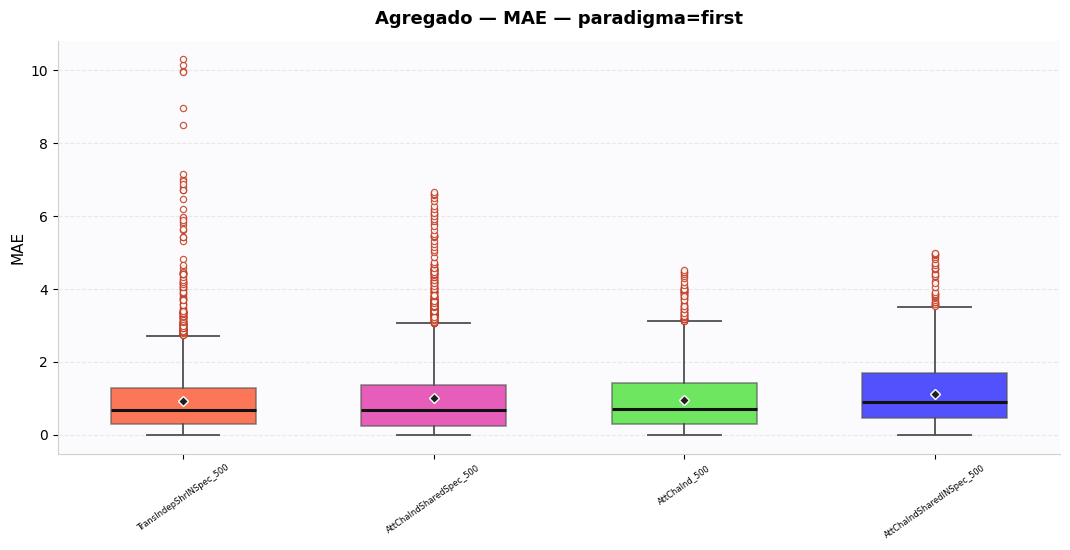

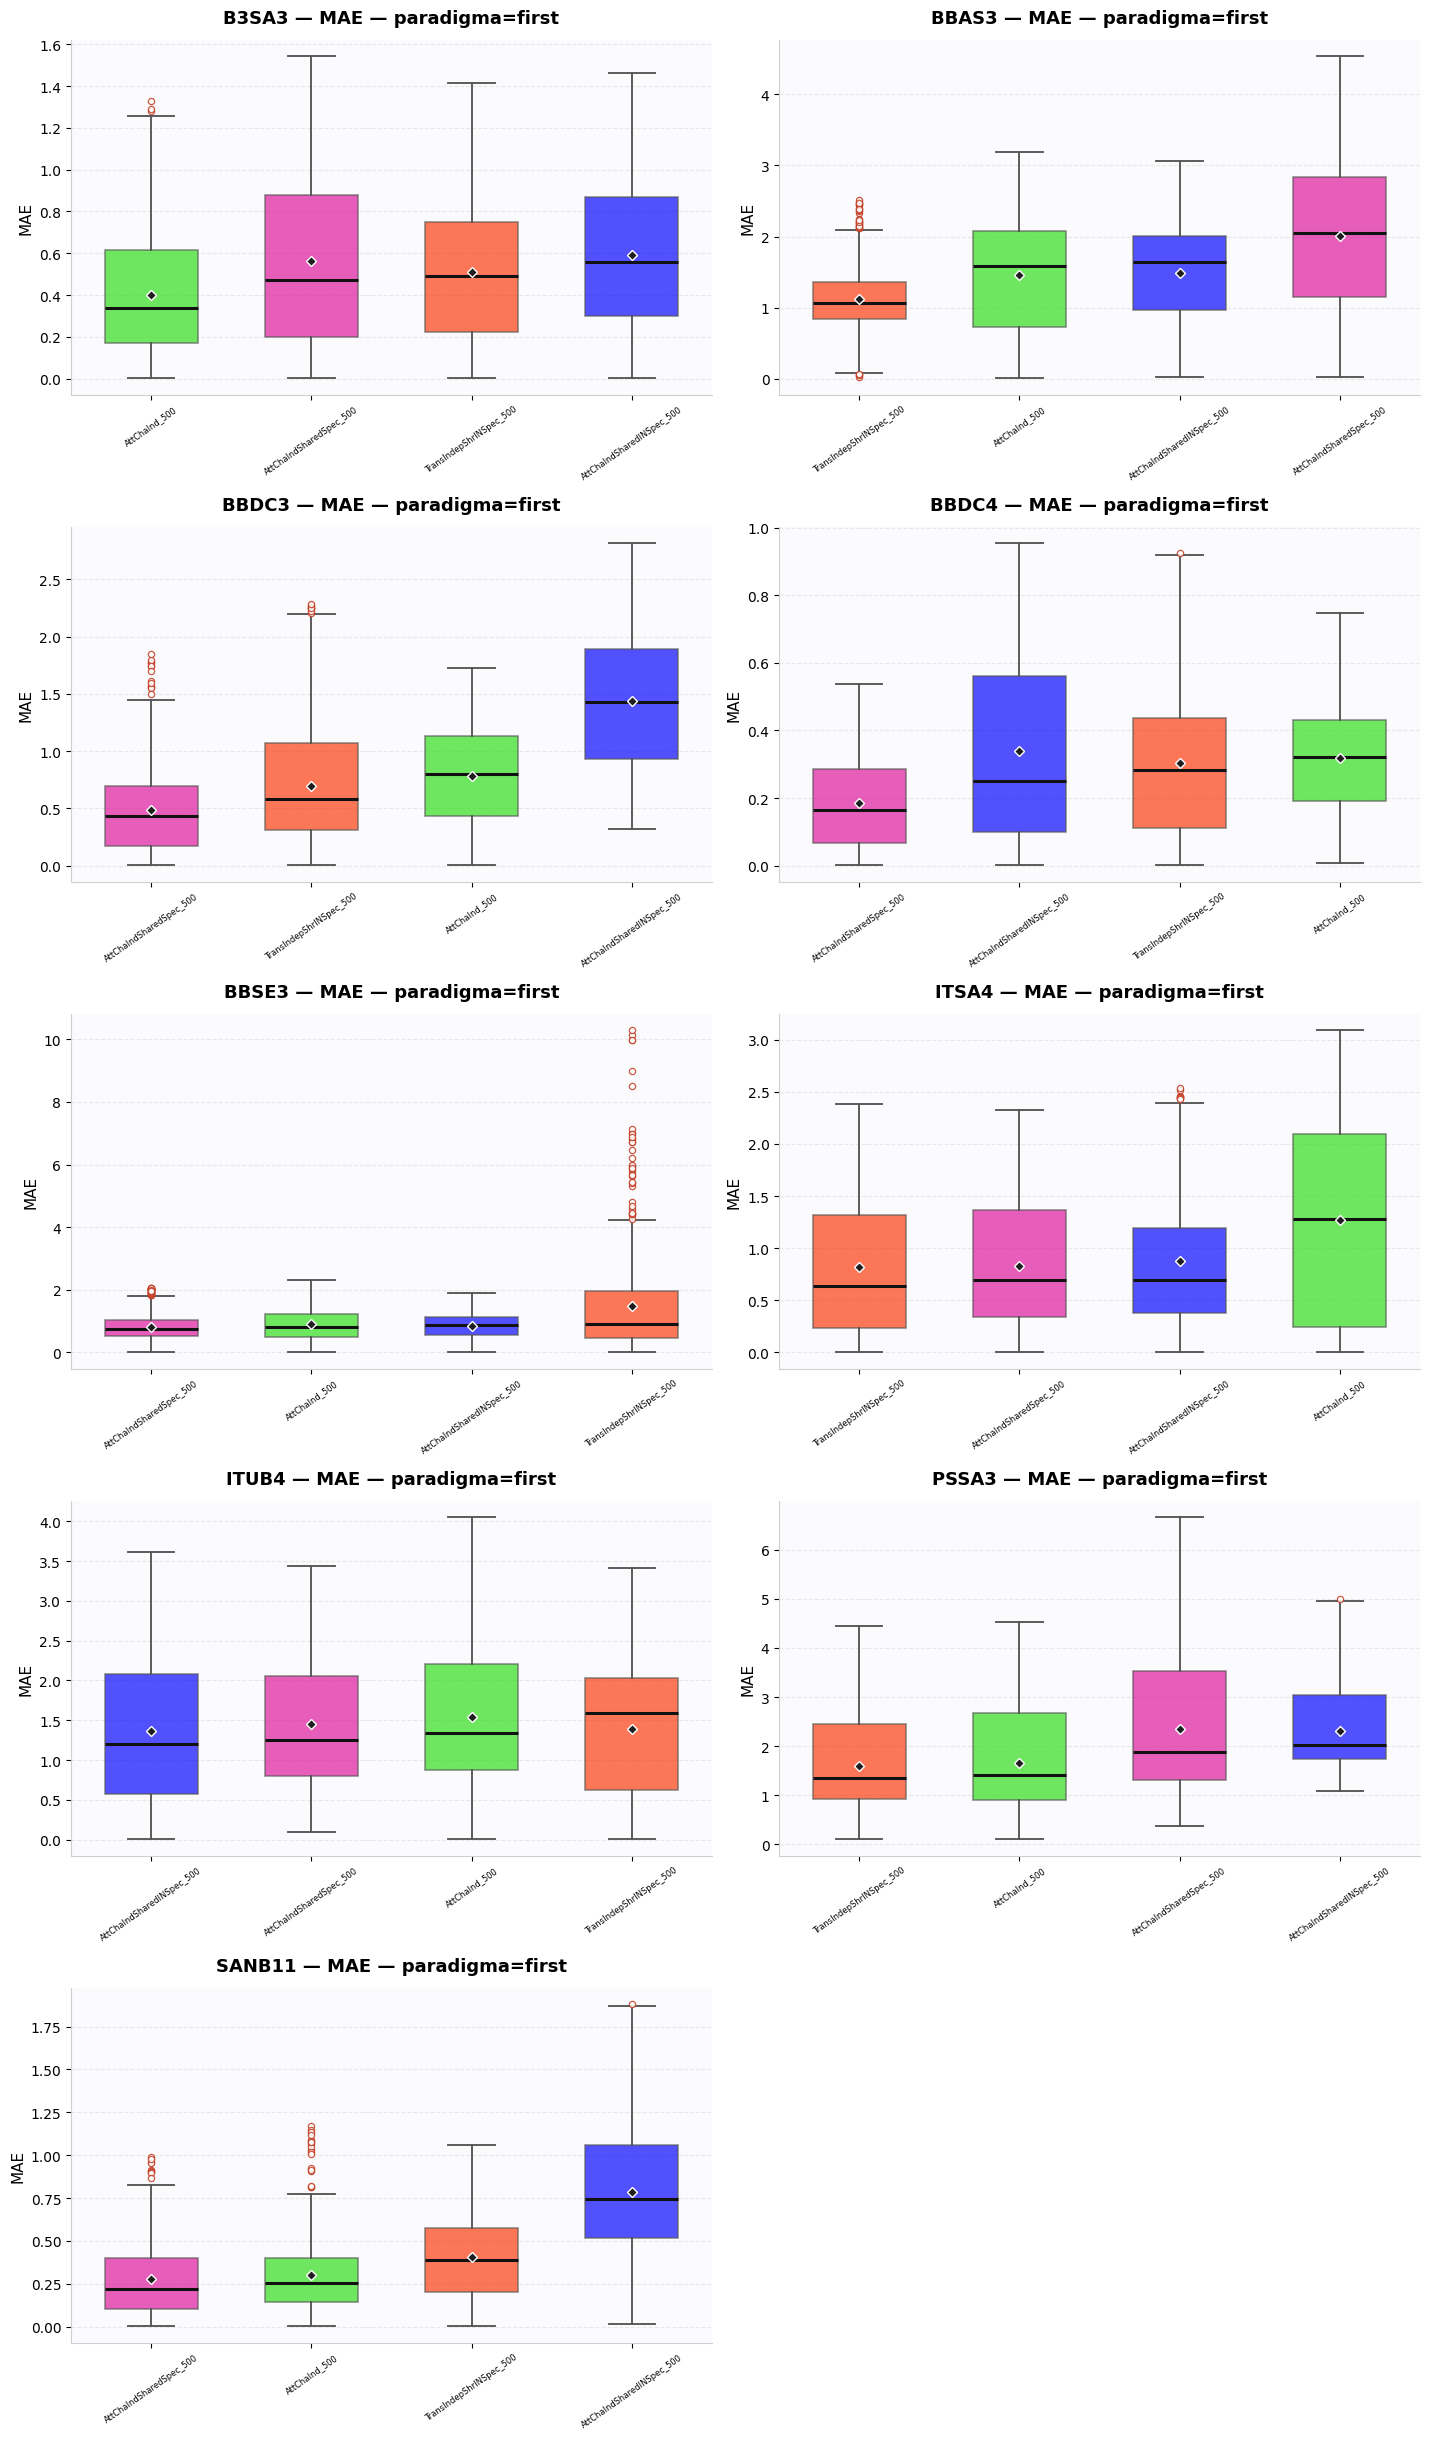

In [82]:
CORES = {r['nome']: r.get('cor', PALETA_PADRAO[i % len(PALETA_PADRAO)]) for i, r in enumerate(registra_modelo)}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#fbfbfd',
    'axes.edgecolor': '#d0d0d0',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 6,
    'ytick.labelsize': 10,
    
})


for metrica in METRICAS:
    fig, ax = plt.subplots(figsize=(10.8, 5.6))
    boxplot_moderno(ax, metricas_boxplot, metrica, 'Agregado — ' + metrica + ' — paradigma=' + PARADIGMA)
    plt.tight_layout()
    plt.show()

for metrica in METRICAS:
    plot_grade_por_papel(metricas_boxplot, metrica, max_cols=2)


In [199]:
NOME_PASTA_OUTPUT = 'sandbox'
PASTA_SAIDA = Path('outputs') / NOME_PASTA_OUTPUT
PASTA_DADOS = PASTA_SAIDA / 'dados'
PASTA_GRAFICOS = PASTA_SAIDA / 'graficos'

PASTA_DADOS.mkdir(parents=True, exist_ok=True)
PASTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

FORMATOS_GRAFICOS = ['png', 'pdf']
DPI_GRAFICOS = 300

# Salva dados
base_erros.to_csv(PASTA_DADOS / ('base_erros_' + PARADIGMA + '.csv'), index=False)
metricas_por_serie.to_csv(PASTA_DADOS / ('metricas_por_serie_' + PARADIGMA + '.csv'), index=False)
metricas_boxplot.to_csv(PASTA_DADOS / ('metricas_usadas_boxplot_' + PARADIGMA + '.csv'), index=False)
metricas_agregado_geral.to_csv(PASTA_DADOS / ('metricas_agregado_geral_' + PARADIGMA + '.csv'), index=False)

if not metricas_por_lote_serie.empty:
    metricas_por_lote_serie.to_csv(
        PASTA_DADOS / ('metricas_por_lote_serie_' + PARADIGMA + '.csv'),
        index=False,
    )




for metrica in METRICAS:
    salvar_boxplot_agregado(metricas_boxplot, metrica)
    salvar_grade_por_papel(metricas_boxplot, metrica, max_cols=2)

print('Dados salvos em:', PASTA_DADOS.resolve())
print('Gráficos salvos em:', PASTA_GRAFICOS.resolve())

Dados salvos em: /sonic_home/igor.viveiros/paralelo/outputs/sandbox/dados
Gráficos salvos em: /sonic_home/igor.viveiros/paralelo/outputs/sandbox/graficos
